# New EDA notebook

## Making graphs

In [4]:
# Imports and configuration

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Robust project root detection:
# start from current working directory and go up until we find a
# directory that contains a "data" folder (or pyproject.toml).
PROJECT_ROOT = Path.cwd().resolve()
for _ in range(5):  # safety limit
    if (PROJECT_ROOT / "data").exists() or (PROJECT_ROOT / "pyproject.toml").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"Using processed data from: {PROCESSED_DIR}")


def load_pkl(path: Path):
    """Small helper to load pickle files with a consistent message."""
    print(f"Loading {path} ...")
    with open(path, "rb") as f:
        return pickle.load(f)


PROJECT_ROOT = /Users/glouno/sourceCode/DALAS-Project
Using processed data from: /Users/glouno/sourceCode/DALAS-Project/data/processed


In [5]:
# Load processed datasets

final_drugs_df = load_pkl(PROCESSED_DIR / "final_drugs_df.pkl")
final_diseases_df = load_pkl(PROCESSED_DIR / "final_diseases_df.pkl")
final_trials_df = load_pkl(PROCESSED_DIR / "final_trials_df.pkl")
final_indications_df = load_pkl(PROCESSED_DIR / "final_indications_df.pkl")

embeddings_df = load_pkl(PROCESSED_DIR / "embeddings_df.pkl")
fingerprints_df = load_pkl(PROCESSED_DIR / "fingerprints_df.pkl")
labeled_indications_df = load_pkl(PROCESSED_DIR / "labeled_indications_df.pkl")
merged_df = load_pkl(PROCESSED_DIR / "merged_df.pkl")

print("\nShapes:")
for name, df in [
    ("final_drugs_df", final_drugs_df),
    ("final_diseases_df", final_diseases_df),
    ("final_trials_df", final_trials_df),
    ("final_indications_df", final_indications_df),
    ("embeddings_df", embeddings_df),
    ("fingerprints_df", fingerprints_df),
    ("labeled_indications_df", labeled_indications_df),
    ("merged_df", merged_df),
]:
    print(f"  {name:24s}: {df.shape}")

Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/final_drugs_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/final_diseases_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/final_trials_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/final_indications_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/embeddings_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/fingerprints_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/labeled_indications_df.pkl ...
Loading /Users/glouno/sourceCode/DALAS-Project/data/processed/merged_df.pkl ...

Shapes:
  final_drugs_df          : (2479, 44)
  final_diseases_df       : (197, 7)
  final_trials_df         : (6993, 8)
  final_indications_df    : (7637, 10)
  embeddings_df           : (454282, 5)
  fingerprints_df         : (1541, 101)
  labeled_indications_df  : (7637, 11)
  merged_df               

In [6]:
# Quick overview of merged dataset

print("Merged dataset preview:")
display(merged_df.head())

print("\nLabel distribution (merged_df):")
label_counts = merged_df["label"].value_counts().sort_index()
label_props = merged_df["label"].value_counts(normalize=True).sort_index()
summary = pd.DataFrame({"count": label_counts, "proportion": label_props})
summary.index = summary.index.astype(str)
display(summary)

print("\nBasic stats (first_approval, usan_year, name_similarity):")
cols = [c for c in ["first_approval", "usan_year", "name_similarity"] if c in merged_df.columns]
display(merged_df[cols].describe(include="all"))

Merged dataset preview:


,label,biotherapeutic,black_box_warning,chemical_probe,first_approval,first_in_class,inorganic_flag,natural_product,orphan,prodrug,...,disease_path_41,disease_path_42,disease_path_43,disease_path_44,disease_path_45,disease_path_46,disease_path_47,disease_path_48,disease_path_49,name_similarity
2,True,0.0,1.0,0.0,1966.0,0.0,0.0,1.0,0.0,0.0,...,0.008980,0.020822,-0.014980,0.075704,0.026394,-0.015165,0.038097,0.006377,0.044797,0.075027
8,True,0.0,1.0,0.0,1994.0,0.0,0.0,1.0,1.0,0.0,...,0.047681,0.000221,0.142663,-0.020573,-0.047975,0.050837,0.009025,0.015265,0.072810,0.249712
12,True,0.0,1.0,0.0,1998.0,0.0,0.0,0.0,0.0,0.0,...,0.033277,-0.012923,0.043356,0.082709,-0.057172,0.028513,-0.014135,0.021263,-0.003842,0.125380
13,True,0.0,1.0,0.0,1998.0,0.0,0.0,0.0,0.0,0.0,...,0.015464,-0.054782,0.013591,-0.017647,0.029517,0.018938,-0.031048,-0.053950,-0.043948,0.221504
15,True,0.0,0.0,0.0,1995.0,0.0,0.0,0.0,0.0,0.0,...,0.047681,0.000221,0.142663,-0.020573,-0.047975,0.050837,0.009025,0.015265,0.072810,0.144043



Label distribution (merged_df):


,count,proportion
label,,
False,1464,0.702495
True,620,0.297505



Basic stats (first_approval, usan_year, name_similarity):


,first_approval,usan_year,name_similarity
count,1271.000000,1303.000000,2084.000000
mean,1989.097561,1998.544129,0.113084
std,21.440412,17.757567,0.098246
min,1940.000000,1961.000000,-0.136201
25%,1973.000000,1986.000000,0.044554
50%,1994.000000,2004.000000,0.104813
75%,2006.000000,2013.000000,0.170700
max,2024.000000,2024.000000,0.543056


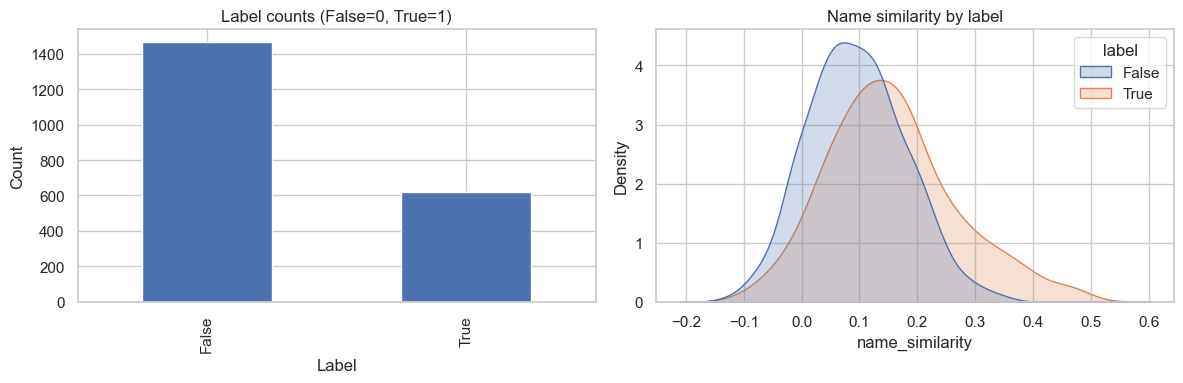

In [7]:
# Visualize label distribution and name similarity

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot of labels
label_counts.plot(kind="bar", ax=axes[0])
axes[0].set_title("Label counts (False=0, True=1)")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")

# Name similarity by label
if "name_similarity" in merged_df.columns:
    sns.kdeplot(
        data=merged_df,
        x="name_similarity",
        hue="label",
        common_norm=False,
        fill=True,
        ax=axes[1],
    )
    axes[1].set_title("Name similarity by label")
else:
    axes[1].text(0.5, 0.5, "name_similarity not found", ha="center", va="center")

plt.tight_layout()
plt.show()

Drugs: basic info
      drug_id      drug_name max_phase  biotherapeutic  black_box_warning
0     CHEMBL3       nicotine       4.0             0.0                0.0
1  CHEMBL6246   ellagic acid       2.0             0.0                0.0
2     CHEMBL6   indomethacin       4.0             0.0                1.0
3   CHEMBL404     tazobactam       4.0             0.0                0.0
4     CHEMBL8  ciprofloxacin       4.0             0.0                1.0


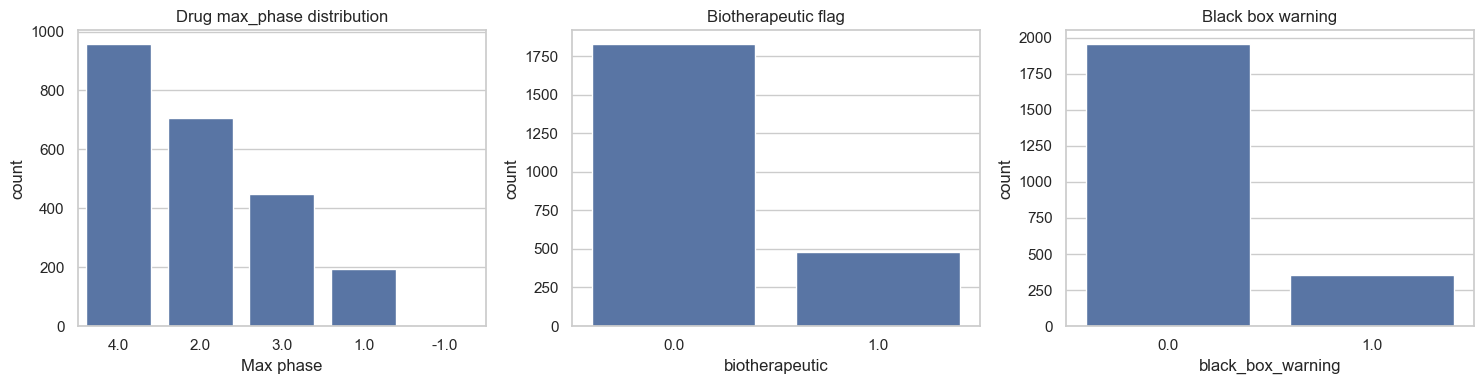


Missing values in key drug columns:


,missing_fraction
first_approval,0.615974
usan_year,0.453409
canonical_smiles,0.378378


In [8]:
# Drug-level EDA

print("Drugs: basic info")
print(final_drugs_df[["drug_id", "drug_name", "max_phase", "biotherapeutic", "black_box_warning"]].head())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Max phase distribution
sns.countplot(x="max_phase", data=final_drugs_df, ax=axes[0])
axes[0].set_title("Drug max_phase distribution")
axes[0].set_xlabel("Max phase")

# Biotherapeutic vs small molecule
if "biotherapeutic" in final_drugs_df.columns:
    sns.countplot(x="biotherapeutic", data=final_drugs_df, ax=axes[1])
    axes[1].set_title("Biotherapeutic flag")

# Black box warning
if "black_box_warning" in final_drugs_df.columns:
    sns.countplot(x="black_box_warning", data=final_drugs_df, ax=axes[2])
    axes[2].set_title("Black box warning")

plt.tight_layout()
plt.show()

print("\nMissing values in key drug columns:")
display(final_drugs_df[[
    "first_approval",
    "usan_year",
    "canonical_smiles",
]].isna().mean().to_frame("missing_fraction"))

In [9]:
# Disease-level EDA

print("Diseases: basic info")
print(final_diseases_df[["disease_id", "name"]].head())

# Approximate prevalence of diseases in merged dataset
if "disease_id" in merged_df.columns:
    disease_counts = merged_df["disease_id"].value_counts().head(15)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=disease_counts.values, y=disease_counts.index)
    plt.title("Top 15 diseases by number of drug pairs")
    plt.xlabel("# drug-disease pairs")
    plt.ylabel("disease_id")
    plt.tight_layout()
    plt.show()

Diseases: basic info
    disease_id                  name
0  EFO_0000685  rheumatoid arthritis
1  EFO_0000574              lymphoma
2  EFO_0000274         atopic eczema
3  EFO_0001378      multiple myeloma
4  EFO_0004991     Myasthenia gravis


Indications with labels (labeled_indications_df):
         drug_id       efo_id  max_phase_for_ind  n_trials  label
0  CHEMBL1201823  EFO:0000685                4.0        22   True
1  CHEMBL1201580  EFO:0000685                4.0        38   True
2     CHEMBL1467  EFO:0000574                4.0         1   True
3   CHEMBL514800  EFO:0000274                2.0         1   <NA>
4     CHEMBL1471  EFO:0001378                3.0         1   <NA>


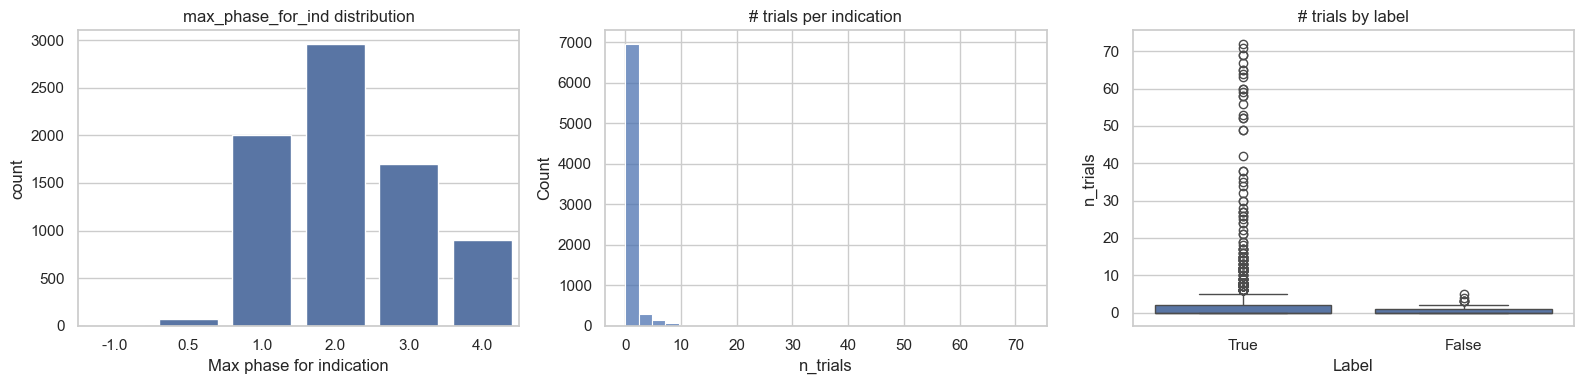

In [14]:
# Indications and trials EDA

print("Indications with labels (labeled_indications_df):")

# Columns differ slightly between notebook and scripts. In the scripts, we have
# drug_id + efo_id (and create disease_id later during merge), so we select
# whatever is available among these.
cols_to_show = [
    c for c in [
        "drug_id",
        "disease_id",  # may or may not exist
        "efo_id",
        "max_phase_for_ind",
        "n_trials",
        "label",
    ]
    if c in labeled_indications_df.columns
]
print(labeled_indications_df[cols_to_show].head())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Max phase for indication
if "max_phase_for_ind" in labeled_indications_df.columns:
    sns.countplot(x="max_phase_for_ind", data=labeled_indications_df, ax=axes[0])
    axes[0].set_title("max_phase_for_ind distribution")
    axes[0].set_xlabel("Max phase for indication")
else:
    axes[0].text(0.5, 0.5, "max_phase_for_ind not found", ha="center", va="center")

# n_trials distribution
if "n_trials" in labeled_indications_df.columns:
    sns.histplot(labeled_indications_df["n_trials"], bins=30, ax=axes[1])
    axes[1].set_title("# trials per indication")
else:
    axes[1].text(0.5, 0.5, "n_trials not found", ha="center", va="center")

# n_trials by label – handle nullable boolean labels safely
if "n_trials" in labeled_indications_df.columns and "label" in labeled_indications_df.columns:
    tmp = labeled_indications_df.dropna(subset=["n_trials", "label"]).copy()
    # Convert pandas nullable boolean to string for clean seaborn categories
    tmp["label_str"] = tmp["label"].astype(str)
    sns.boxplot(x="label_str", y="n_trials", data=tmp, ax=axes[2])
    axes[2].set_title("# trials by label")
    axes[2].set_xlabel("Label")
    axes[2].set_ylabel("n_trials")
else:
    axes[2].text(0.5, 0.5, "n_trials/label not found", ha="center", va="center")

plt.tight_layout()
plt.show()

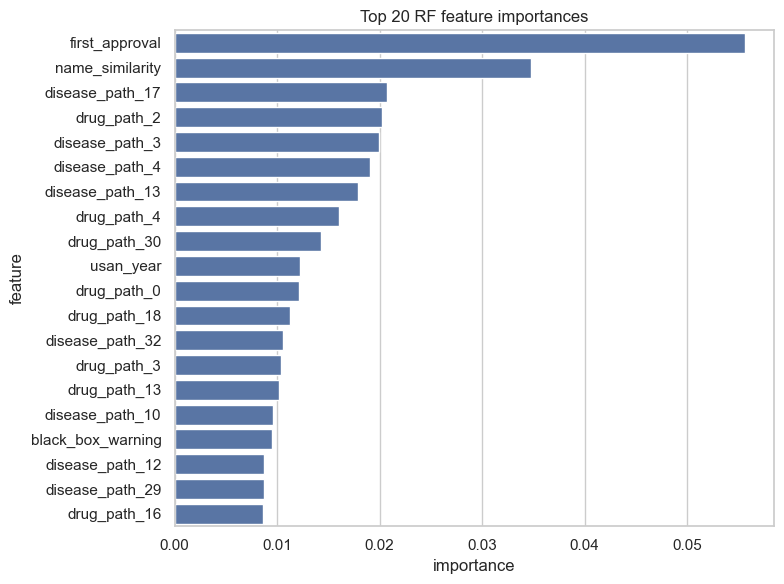

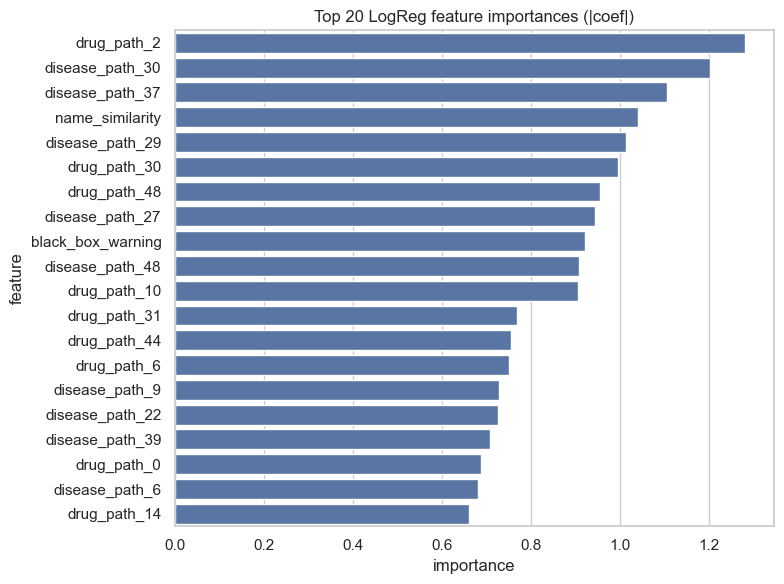

In [12]:
# Feature importance from trained models (if available)

rf_importance_path = PROJECT_ROOT / "results" / "rf_feature_importance.csv"
lr_importance_path = PROJECT_ROOT / "results" / "lr_feature_importance.csv"

if rf_importance_path.exists():
    rf_importance = pd.read_csv(rf_importance_path)
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=rf_importance.head(20),
        x="importance",
        y="feature",
    )
    plt.title("Top 20 RF feature importances")
    plt.tight_layout()
    plt.show()
else:
    print(f"RF feature importance file not found at {rf_importance_path}")

if lr_importance_path.exists():
    lr_importance = pd.read_csv(lr_importance_path)
    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=lr_importance.head(20),
        x="importance",
        y="feature",
    )
    plt.title("Top 20 LogReg feature importances (|coef|)")
    plt.tight_layout()
    plt.show()
else:
    print(f"LogReg feature importance file not found at {lr_importance_path}")

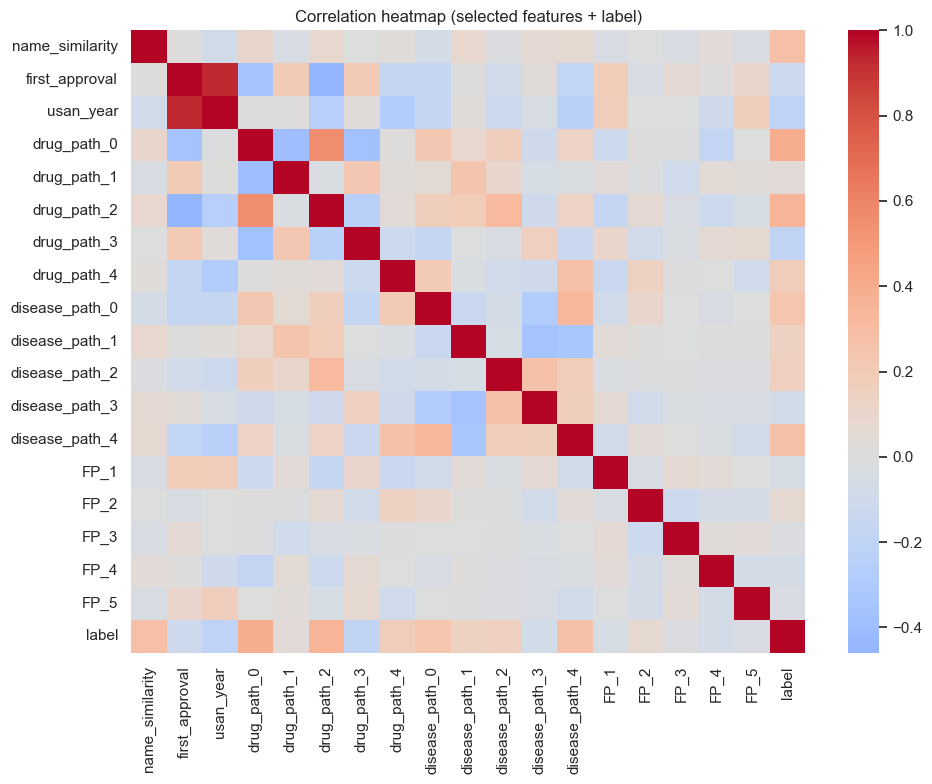

In [13]:
# Correlation heatmap for selected numeric features

numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

# Focus on a subset: core properties, name_similarity, a few path / FP features
candidate_cols = []
for col in [
    "name_similarity",
    "first_approval",
    "usan_year",
    "max_phase",
]:
    if col in numeric_cols:
        candidate_cols.append(col)

# Add some pathway and fingerprint features if present
candidate_cols += [c for c in numeric_cols if c.startswith("drug_path_")][:5]
candidate_cols += [c for c in numeric_cols if c.startswith("disease_path_")][:5]
candidate_cols += [c for c in numeric_cols if c.startswith("FP_")][:5]

candidate_cols = list(dict.fromkeys(candidate_cols))  # deduplicate while preserving order

if len(candidate_cols) >= 2:
    corr = merged_df[candidate_cols + ["label"]].corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation heatmap (selected features + label)")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric features found for correlation heatmap.")